# ML Challenge 

<img src="https://imageio.forbes.com/specials-images/imageserve/5ecd179f798e4c00060d2c7c/0x0.jpg?format=jpg&height=600&width=1200&fit=bounds" width="500" height="300">

In the bustling city of Financia, the Central Lending Institution (CLI) is the largest provider of loans to individuals and businesses. With a mission to support economic growth and financial stability, CLI processes thousands of loan applications every month. However, the traditional manual review process is time-consuming and prone to human error, leading to delays and inconsistencies in loan approvals.
To address these challenges, CLI has decided to leverage the power of machine learning to streamline their loan approval process. They have compiled a comprehensive dataset containing historical loan application records, including various factors such as credit scores, income levels, employment status, loan terms(measured in years), loan amounts, asset values, and the final loan status (approved or denied).


**Your task is to develop a predictive model that can accurately determine the likelihood of loan approval based on the provided features. By doing so, you will help CLI make faster, more accurate, and fairer lending decisions, ultimately contributing to the financial well-being of the community.**

It is recommended that you follow the typical machine learning workflow, though you are not required to strictly follow each steps: 
1. Data Collection: Gather the data you need for your model. (Already done for you)

2. Data Preprocessing: Clean and prepare the data for analysis. (Already done for you)

3. Exploratory Data Analysis (EDA): Understand the data and its patterns. (Partially done for you)

4. Feature Engineering: Create new features or modify existing ones to improve model performance. (Partially done for you)

5. Model Selection: Choose the appropriate machine learning algorithm.

6. Model Training: Train the model using the training dataset.

7. Model Evaluation: Evaluate the model's performance using a validation dataset.

8. Model Optimization: Optimize the model's parameters to improve performance.

9. Model Testing: Test the final model on a separate test dataset.

**Please include ALL your work and thought process in this notebook**

In [6]:
# You may include any package you deem fit. We sugggest looking into Scikit-learn
import pandas as pd
import sklearn as sk
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import xgboost as xgb


## Dataset


In [3]:
# DO NOT MODIFY
loan_data = pd.read_csv("../../data/loan_approval.csv")
loan_data.head()


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [14]:
loan_data_rejects = loan_data[loan_data['loan_status'] == 0]
loan_data_rejects.head(), loan_data_rejects.describe()


(   loan_id  no_of_dependents  education  self_employed  income_annum  \
 1        2                 0          0              1       4100000   
 2        3                 3          1              0       9100000   
 3        4                 3          1              0       8200000   
 4        5                 5          0              1       9800000   
 5        6                 0          1              1       4800000   
 
    loan_amount  loan_term  cibil_score  residential_assets_value  \
 1     12200000          8          417                   2700000   
 2     29700000         20          506                   7100000   
 3     30700000          8          467                  18200000   
 4     24200000         20          382                  12400000   
 5     13500000         10          319                   6800000   
 
    commercial_assets_value  luxury_assets_value  bank_asset_value  loan_status  
 1                  2200000              8800000           330

In [13]:
loan_data_approves = loan_data[loan_data['loan_status'] == 1]
loan_data_approves.head(), loan_data_rejects.describe()


(    loan_id  no_of_dependents  education  self_employed  income_annum  \
 0         1                 2          1              0       9600000   
 6         7                 5          1              0       8700000   
 8         9                 0          1              1        800000   
 10       11                 4          1              1       2900000   
 13       14                 2          1              1       9100000   
 
     loan_amount  loan_term  cibil_score  residential_assets_value  \
 0      29900000         12          778                   2400000   
 6      33000000          4          678                  22500000   
 8       2200000         20          782                   1300000   
 10     11200000          2          547                   8100000   
 13     31500000         14          679                  10800000   
 
     commercial_assets_value  luxury_assets_value  bank_asset_value  \
 0                  17600000             22700000           8

## EDA
Uncomment to see desired output. Add more analysis if you like

Index(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status'],
      dtype='str')
           loan_id  no_of_dependents    education  self_employed  \
count  4269.000000       4269.000000  4269.000000    4269.000000   
mean   2135.000000          2.498712     0.502225       0.503631   
std    1232.498479          1.695910     0.500054       0.500045   
min       1.000000          0.000000     0.000000       0.000000   
25%    1068.000000          1.000000     0.000000       0.000000   
50%    2135.000000          3.000000     1.000000       1.000000   
75%    3202.000000          4.000000     1.000000       1.000000   
max    4269.000000          5.000000     1.000000       1.000000   

       income_annum   loan_amount    loan_term  cibil_score  \
count  4.269000e+03  4.269000e+03  4269.000

([<matplotlib.axis.YTick at 0x1f240c09810>,
 [Text(0, 0, 'loan_id'),
  Text(0, 1, 'no_of_dependents'),
  Text(0, 2, 'education'),
  Text(0, 3, 'self_employed'),
  Text(0, 4, 'income_annum'),
  Text(0, 5, 'loan_amount'),
  Text(0, 6, 'loan_term'),
  Text(0, 7, 'cibil_score'),
  Text(0, 8, 'residential_assets_value'),
  Text(0, 9, 'commercial_assets_value'),
  Text(0, 10, 'luxury_assets_value'),
  Text(0, 11, 'bank_asset_value'),
  Text(0, 12, 'loan_status')])

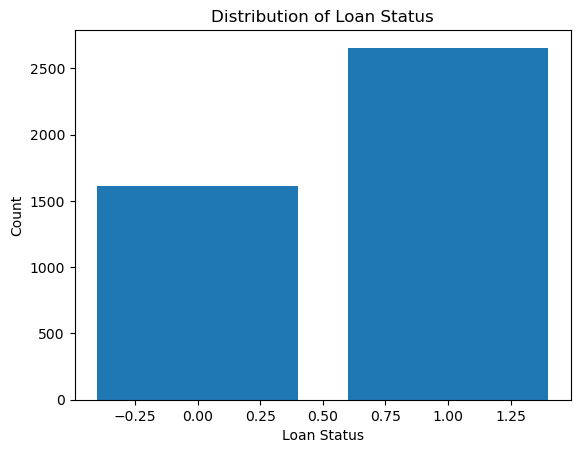

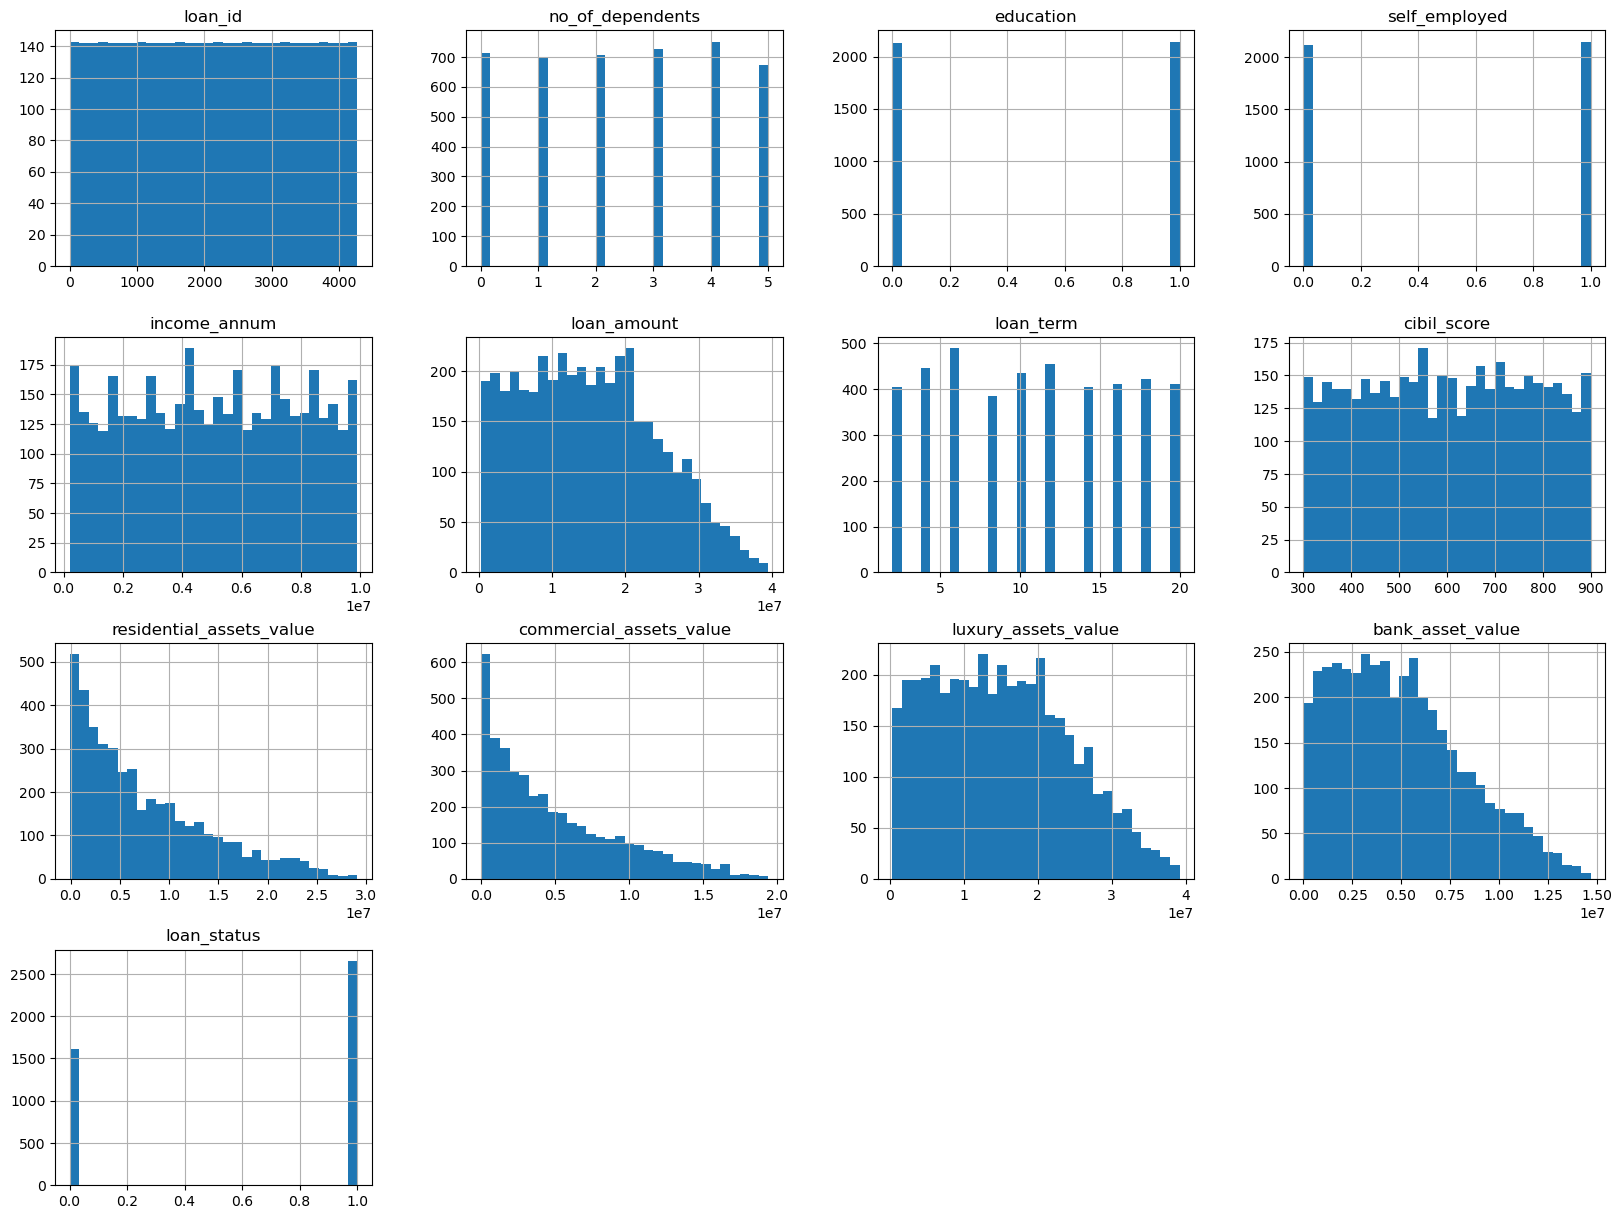

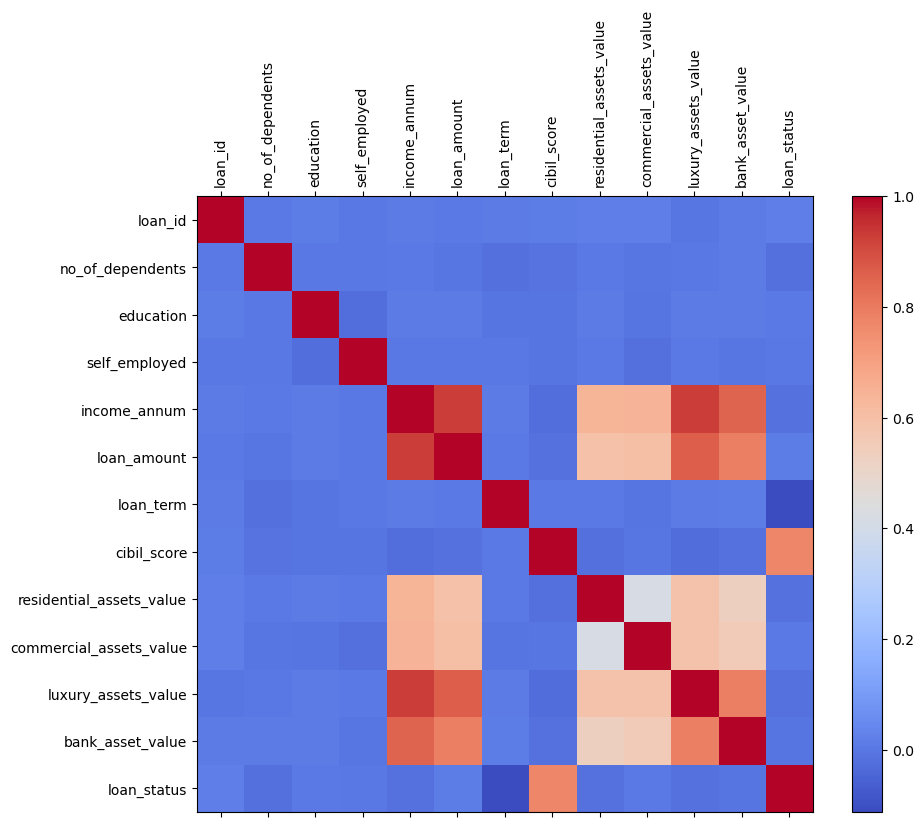

In [10]:

import matplotlib.pyplot as plt

# ------ Display basic information ------
print(loan_data.columns)
print(loan_data.describe())

# ------ Check for missing values ------
print(loan_data.isnull().sum())

# ------ Visualize the distribution of loan status ------
loan_status_counts = loan_data['loan_status'].value_counts()
plt.bar(loan_status_counts.index, loan_status_counts.values)
plt.title('Distribution of Loan Status')
plt.xlabel('Loan Status')
plt.ylabel('Count')

# ------ Visualize the distribution of numerical features ------ 
loan_data.hist(bins=30, figsize=(20, 15))
# ------ Correlation matrix ------
loan_data = loan_data.copy()
loan_data['education'] = loan_data['education'].replace({'Graduate': 1, 'Not Graduate': 0})
loan_data['self_employed'] = loan_data['self_employed'].replace({'Yes': 1, 'No': 0})
loan_data['loan_status'] = loan_data['loan_status'].replace({
    'Approved': 1, 'Rejected': 0,
    'Y': 1, 'N': 0
})
loan_data = loan_data.apply(pd.to_numeric, errors='coerce')
corr_matrix = loan_data.corr()
fig, ax = plt.subplots(figsize=(10, 8))
cax = ax.matshow(corr_matrix, cmap='coolwarm')
fig.colorbar(cax)
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

# ----- MORE (Encouraged but not required) ------
# TODO 

## Feature Engineering

You may want to convert categorical variables to numerical. For example, education takes on the value Graduate and Not Graduate. But we want it to be 0 or 1 for machine learning algorithms to use.

In [ ]:
loan_model_data = loan_data.copy()

# Robust target encoding: 1 means rejected, 0 means approved.
# This works whether loan_status is still text or was already converted in EDA.
if not pd.api.types.is_numeric_dtype(loan_model_data['loan_status']):
    loan_model_data['loan_rejected'] = loan_model_data['loan_status'].map({
        'Rejected': 1,
        'Approved': 0,
        'N': 1,
        'Y': 0
    })
else:
    loan_model_data['loan_rejected'] = 1 - loan_model_data['loan_status']

# Total asset value across the asset columns.
asset_columns = [
    'residential_assets_value',
    'commercial_assets_value',
    'luxury_assets_value',
    'bank_asset_value'
]
loan_model_data['total_assets_value'] = loan_model_data[asset_columns].sum(axis=1)

# Ratio features selected from the loan approval analysis.
loan_model_data['loan_amount_to_income'] = (
    loan_model_data['loan_amount'] / loan_model_data['income_annum']
)

loan_model_data['loan_amount_to_total_assets'] = (
    loan_model_data['loan_amount'] /
    loan_model_data['total_assets_value'].replace(0, 1)
)

loan_model_data['loan_amount_to_bank_asset_value'] = (
    loan_model_data['loan_amount'] /
    loan_model_data['bank_asset_value'].replace(0, 1)
)

# Add 1 so applicants with zero dependents still have a valid income per-household-member feature.
loan_model_data['income_annum_per_dependent'] = (
    loan_model_data['income_annum'] / (loan_model_data['no_of_dependents'] + 1)
)

selected_features = [
    'cibil_score',
    'loan_term',
    'loan_amount',
    'residential_assets_value',
    'loan_amount_to_income',
    'loan_amount_to_total_assets',
    'loan_amount_to_bank_asset_value',
    'income_annum_per_dependent'
]

X = loan_model_data[selected_features]
y = loan_model_data['loan_rejected']

X.head(), y.head()


(   cibil_score  loan_term  loan_amount  residential_assets_value  \
 0          778         12     29900000                   2400000   
 1          417          8     12200000                   2700000   
 2          506         20     29700000                   7100000   
 3          467          8     30700000                  18200000   
 4          382         20     24200000                  12400000   
 
    loan_amount_to_income  loan_amount_to_total_assets  \
 0               3.114583                     0.589744   
 1               2.975610                     0.717647   
 2               3.263736                     0.514731   
 3               3.743902                     0.582543   
 4               2.469388                     0.440000   
 
    loan_amount_to_bank_asset_value  income_annum_per_dependent  
 0                         3.737500                3.200000e+06  
 1                         3.696970                4.100000e+06  
 2                         2.320312 

## Model Selection

You are free to use any classification machine learning models you like: Logistic Regression, Decision Trees/Random Forests, Support Vector Machines, KNN ... 

In [19]:
# XGBoost is a good fit for this tabular classification problem because it canapture nonlinear relationships between credit score, loan size, term, and assets.
xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

xgb_model

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


## Model Training and Evaluation

In [20]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# 70/15/15 train-validation-test split.
# First hold out 30%, then split that held-out portion evenly into validation and test sets.
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

xgb_model.fit(X_train, y_train)

val_pred = xgb_model.predict(X_val)
val_proba = xgb_model.predict_proba(X_val)[:, 1]

print("Training observations:", len(X_train))
print("Validation observations:", len(X_val))
print("Testing observations:", len(X_test))

print("\nValidation Set Results")
print("Accuracy:", accuracy_score(y_val, val_pred))
print("Precision for rejected loans:", precision_score(y_val, val_pred))
print("Recall for rejected loans:", recall_score(y_val, val_pred))
print("F1 for rejected loans:", f1_score(y_val, val_pred))
print("ROC-AUC:", roc_auc_score(y_val, val_proba))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, val_pred))

print("\nClassification Report:")
print(classification_report(y_val, val_pred, target_names=['Approved', 'Rejected']))

Training observations: 2988
Validation observations: 640
Testing observations: 641

Validation Set Results
Accuracy: 0.9984375
Precision for rejected loans: 1.0
Recall for rejected loans: 0.9958677685950413
F1 for rejected loans: 0.9979296066252588
ROC-AUC: 1.0

Confusion Matrix:
[[398   0]
 [  1 241]]

Classification Report:
              precision    recall  f1-score   support

    Approved       1.00      1.00      1.00       398
    Rejected       1.00      1.00      1.00       242

    accuracy                           1.00       640
   macro avg       1.00      1.00      1.00       640
weighted avg       1.00      1.00      1.00       640



## Model Optimization and Testing

In [21]:
# Report final test-set predictions from the fitted XGBoost model.
# Keep this test set separate from the validation set used above.
test_pred = xgb_model.predict(X_test)
test_proba = xgb_model.predict_proba(X_test)[:, 1]

test_results = X_test.copy()
test_results['actual_loan_rejected'] = y_test.values
test_results['predicted_loan_rejected'] = test_pred
test_results['rejection_probability'] = test_proba

test_results['actual_status'] = test_results['actual_loan_rejected'].map({
    0: 'Approved',
    1: 'Rejected'
})

test_results['predicted_status'] = test_results['predicted_loan_rejected'].map({
    0: 'Approved',
    1: 'Rejected'
})

print("Final Test Set Results")
print("Accuracy:", accuracy_score(y_test, test_pred))
print("Precision for rejected loans:", precision_score(y_test, test_pred))
print("Recall for rejected loans:", recall_score(y_test, test_pred))
print("F1 for rejected loans:", f1_score(y_test, test_pred))
print("ROC-AUC:", roc_auc_score(y_test, test_proba))

print("\nPrediction counts:")
print(test_results['predicted_status'].value_counts())

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, test_pred))

print("\nClassification Report:")
print(classification_report(y_test, test_pred, target_names=['Approved', 'Rejected']))

feature_importance = pd.DataFrame({
    'feature': selected_features,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFeature importance:")
display(feature_importance)

test_results.head(20)

Final Test Set Results
Accuracy: 1.0
Precision for rejected loans: 1.0
Recall for rejected loans: 1.0
F1 for rejected loans: 1.0
ROC-AUC: 1.0

Prediction counts:
predicted_status
Approved    399
Rejected    242
Name: count, dtype: int64

Confusion Matrix:
[[399   0]
 [  0 242]]

Classification Report:
              precision    recall  f1-score   support

    Approved       1.00      1.00      1.00       399
    Rejected       1.00      1.00      1.00       242

    accuracy                           1.00       641
   macro avg       1.00      1.00      1.00       641
weighted avg       1.00      1.00      1.00       641


Feature importance:


,feature,importance
0,cibil_score,0.796193
1,loan_term,0.086141
4,loan_amount_to_income,0.073503
5,loan_amount_to_total_assets,0.024428
2,loan_amount,0.006173
6,loan_amount_to_bank_asset_value,0.005784
3,residential_assets_value,0.004746
7,income_annum_per_dependent,0.003033


,cibil_score,loan_term,loan_amount,residential_assets_value,loan_amount_to_income,loan_amount_to_total_assets,loan_amount_to_bank_asset_value,income_annum_per_dependent,actual_loan_rejected,predicted_loan_rejected,rejection_probability,actual_status,predicted_status
3474,550,16,16800000,10700000,3.111111,0.448000,2.400000,1.350000e+06,0,0,0.000361,Approved,Approved
1162,620,4,4200000,4700000,2.210526,0.264151,4.666667,9.500000e+05,0,0,0.000485,Approved,Approved
3714,708,20,10500000,4200000,3.620690,0.625000,2.441860,9.666667e+05,0,0,0.000268,Approved,Approved
1850,766,18,25100000,6900000,3.217949,0.613692,2.460784,3.900000e+06,0,0,0.000288,Approved,Approved
846,803,18,23000000,18700000,3.285714,0.404218,5.609756,1.166667e+06,0,0,0.000477,Approved,Approved
17,780,14,9400000,2900000,3.241379,0.562874,2.186047,5.800000e+05,0,0,0.000235,Approved,Approved
3784,885,4,21200000,18000000,2.163265,0.256970,1.962963,4.900000e+06,0,0,0.000437,Approved,Approved
341,465,8,21000000,11700000,2.441860,0.375000,2.121212,1.433333e+06,1,1,0.999650,Rejected,Rejected
2870,847,4,8600000,10200000,2.150000,0.290541,3.583333,1.333333e+06,0,0,0.000416,Approved,Approved
745,587,18,12700000,11000000,3.432432,0.470370,3.097561,9.250000e+05,0,0,0.000355,Approved,Approved
